In [32]:
from database.MongoDBClient import MongoDBClient
from database.Recipe import Recipe
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connect to mongo
mongo = MongoDBClient()

Connected to MongoDB.


In [3]:
# Gather all recipes
recipes = [Recipe.from_dict(doc) for doc in mongo.collection.find()]
print(len(recipes))

122932


In [4]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [7]:
ex_str = recipes[0].to_string(include_id=False, include_source=False)
print(ex_str)

Title: Chicken and Dumplings

Ingredients:
- Skinless, boneless chicken breast halves (4)
- Butter (2 tablespoons)
- Condensed cream of chicken soup (2 cans, 10.75 ounces each)
- Onion, finely diced (1)
- Refrigerated biscuit dough (2 packages, 10 ounces each), torn into pieces

Instructions: Place the chicken, butter, soup, and onion in a slow cooker, and fill with enough water to cover. Cover and cook for 5 to 6 hours on High. About 30 minutes before serving, place the torn biscuit dough in the slow cooker. Cook until the dough is no longer raw in the center.


In [16]:
lengths = [len(tokenizer(r.to_string(include_id=False, include_source=False), 
                         return_tensors='pt').input_ids.flatten()) 
                         for r in recipes]

Token indices sequence length is longer than the specified maximum sequence length for this model (1077 > 1024). Running this sequence through the model will result in indexing errors


In [19]:
len(lengths)

122932

In [22]:
print(np.mean(lengths))
print(np.median(lengths))

346.41584778576777
286.0


In [40]:
too_long = [1 if l > 512 else 0 for l in lengths]
print(sum(too_long))

20431


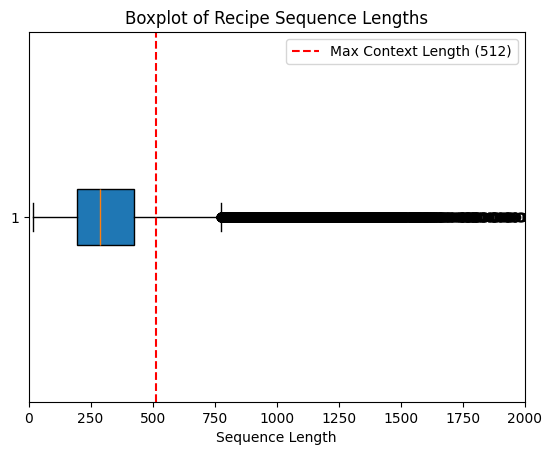

In [35]:
# Create a boxplot
#plt.figure(figsize=(10, 6))
plt.boxplot(lengths, vert=False, patch_artist=True)
plt.axvline(x=512, color='r', linestyle='--', label='Max Context Length (512)')
plt.xlabel("Sequence Length")
plt.title("Boxplot of Recipe Sequence Lengths")
plt.xlim(0, 2000)
plt.legend()
plt.show()

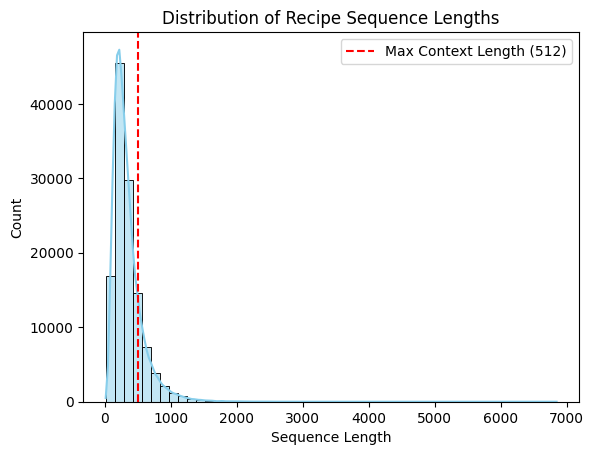

In [36]:
#plt.figure(figsize=(10, 6))
sns.histplot(lengths, kde=True, color="skyblue", bins=50)
plt.axvline(x=512, color='r', linestyle='--', label='Max Context Length (512)')
plt.xlabel("Sequence Length")
plt.title("Distribution of Recipe Sequence Lengths")
plt.legend()
plt.show()

In [52]:
# Longest ones come from which source?
long_recipe = [r for i, r in enumerate(recipes) if too_long[i]]
long_recipe_sources = [r.source for r in long_recipe]
print(long_recipe_sources.count('ar'))
print(long_recipe_sources.count('fn'))
print(long_recipe_sources.count('epi'))

548
9041
10842
